HOTEL OPERATIONS ANALYSIS - FILE LOADED SUCCESSFULLY
Dataset shape : (119390, 32)
Columns       : ['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status', 'reservation_status_date']

HOTEL DATA - FIRST 5 ROWS
          hotel  is_canceled  lead_time  arrival_date_year arrival_date_month  \
0  Resort Hotel            0        342               2015               July   
1  Resort Hotel            0        737               2015               July   
2  Resort Hot

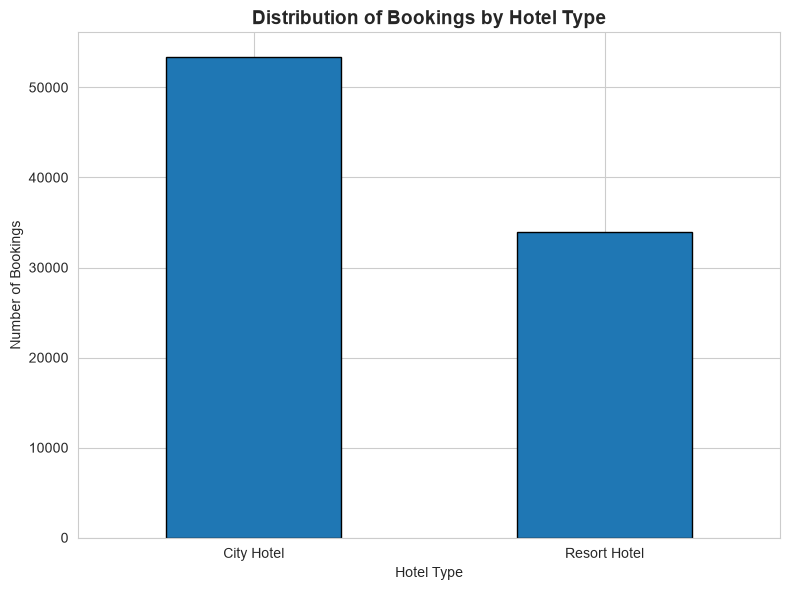

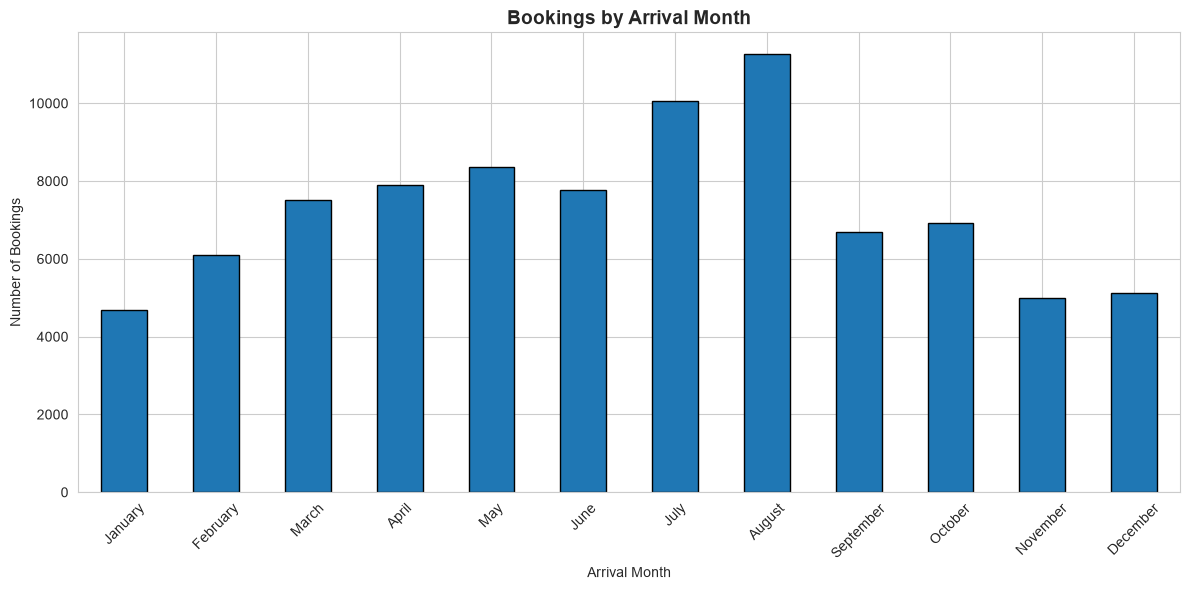

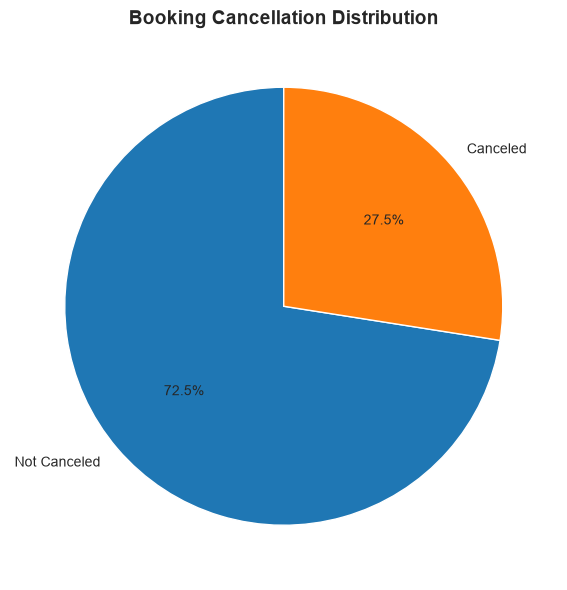

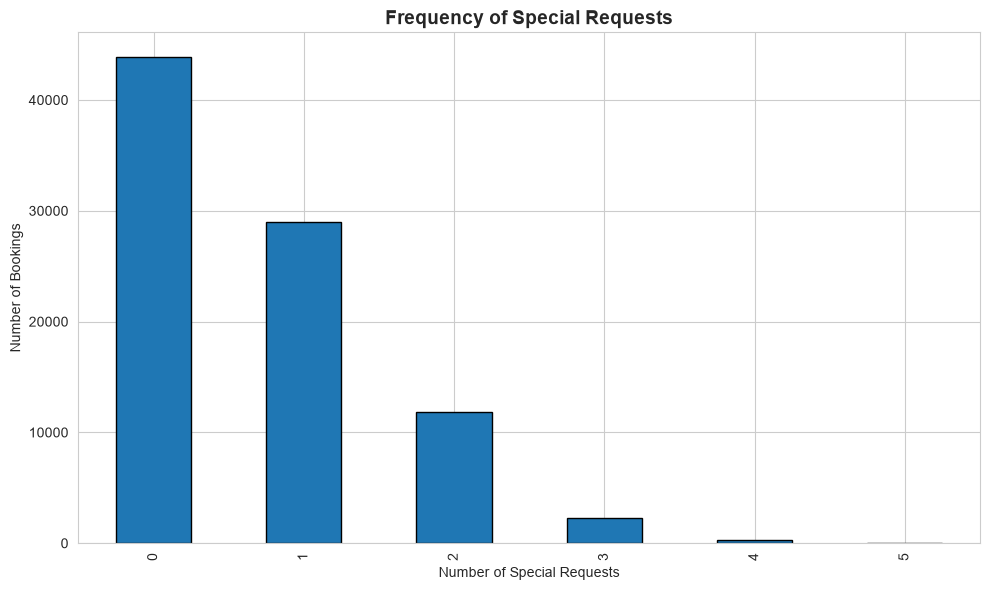

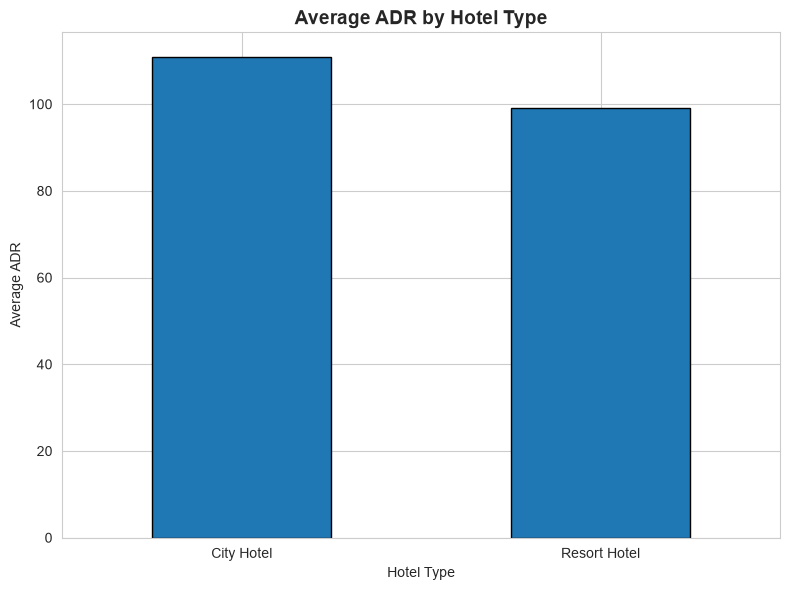

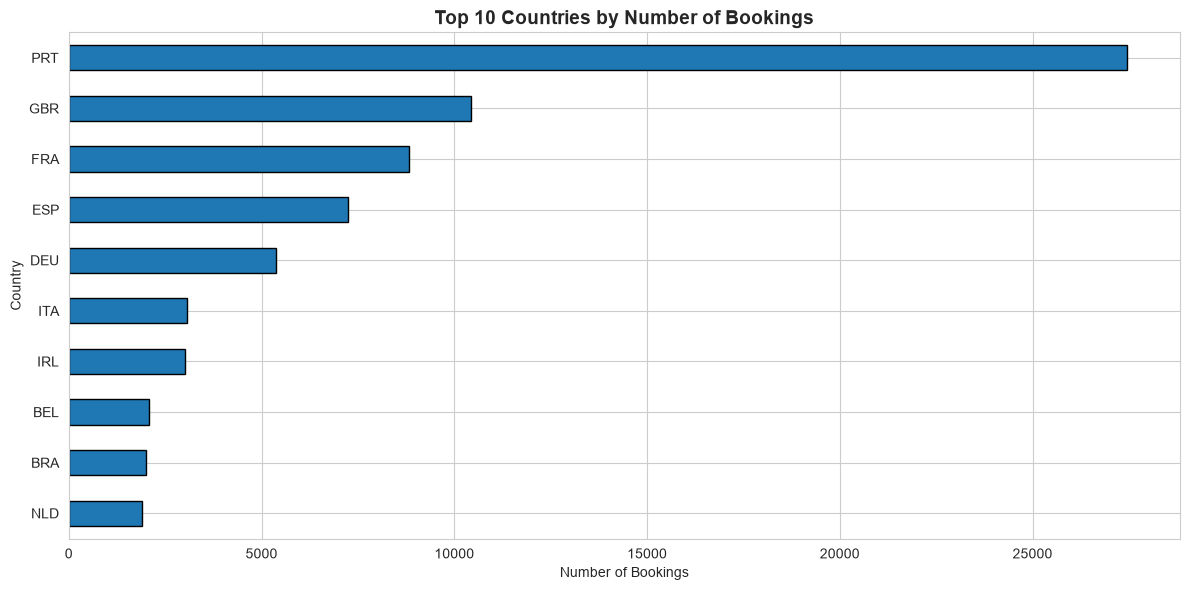


MEDIUM LEVEL QUESTIONS - ANSWERS

1. Cancellation rate for each hotel type (%):
hotel
City Hotel      30.038557
Resort Hotel    23.480923
Name: is_canceled, dtype: float64

2. Average ADR per market segment:
market_segment
Online TA        118.171606
Direct           116.579429
Aviation         100.170396
Offline TA/TO     81.764191
Groups            74.880727
Corporate         68.151246
Undefined         15.000000
Complementary      3.049245
Name: adr, dtype: float64

3. Correlation between lead time and cancellation: 0.1848

4. Distribution channel booking counts:
distribution_channel
TA/TO        69141
Direct       12988
Corporate     5081
GDS            181
Undefined        5
Name: count, dtype: int64
Highest booking distribution channel: TA/TO

5. Average previous cancellations by hotel type:
hotel
City Hotel      0.035768
Resort Hotel    0.021991
Name: previous_cancellations, dtype: float64

6. Average ADR by year:
arrival_date_year
2015     92.160752
2016    101.538903
2017    

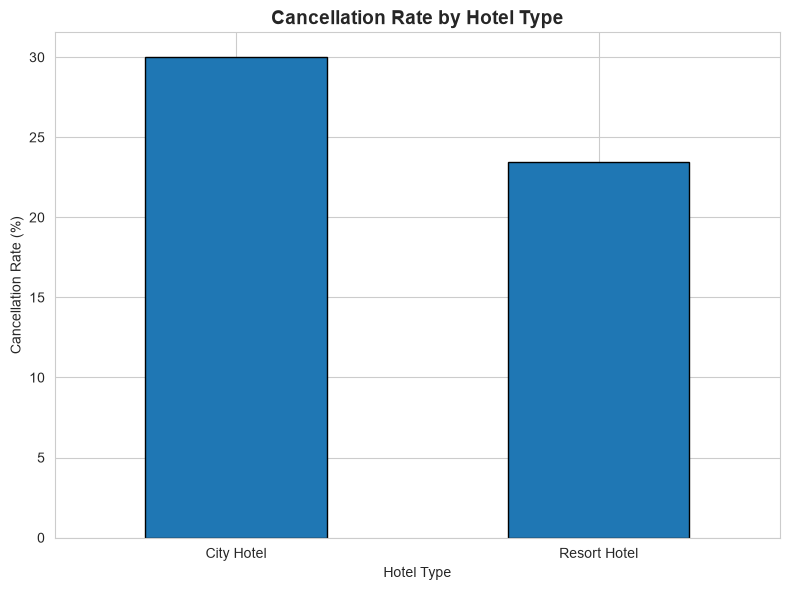

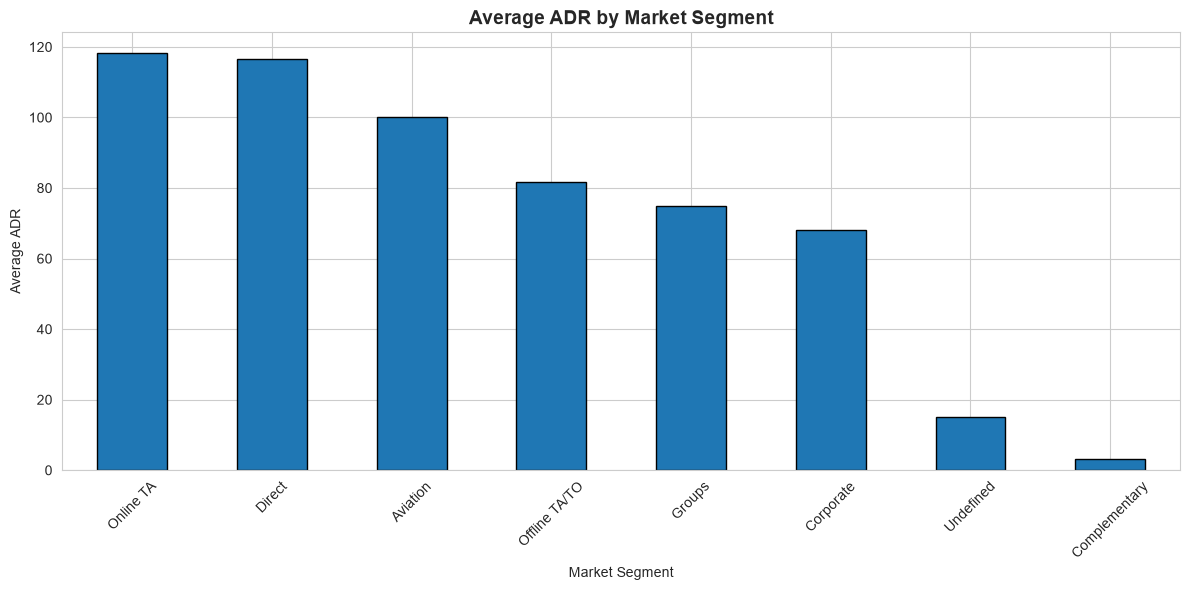

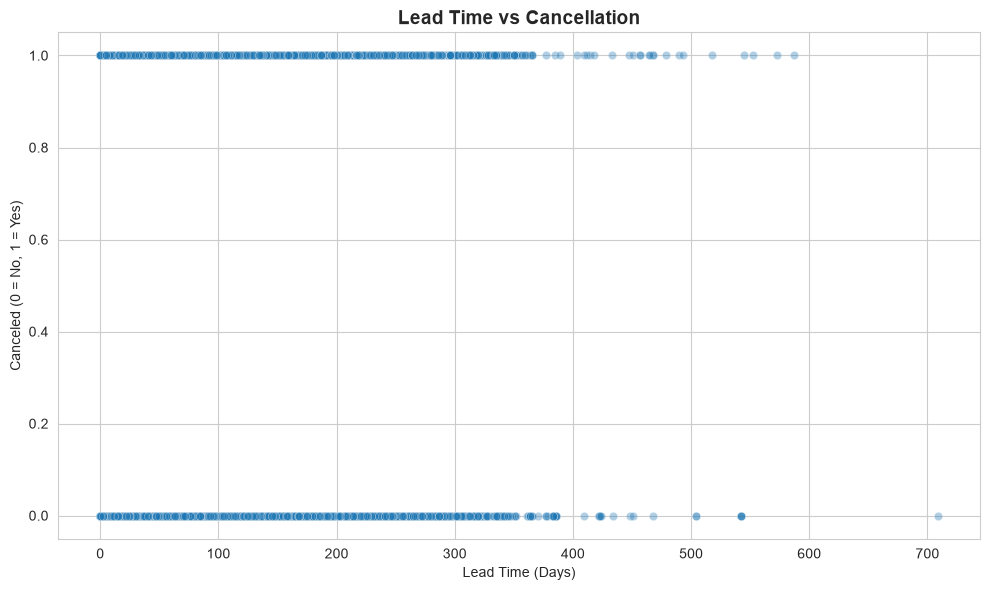

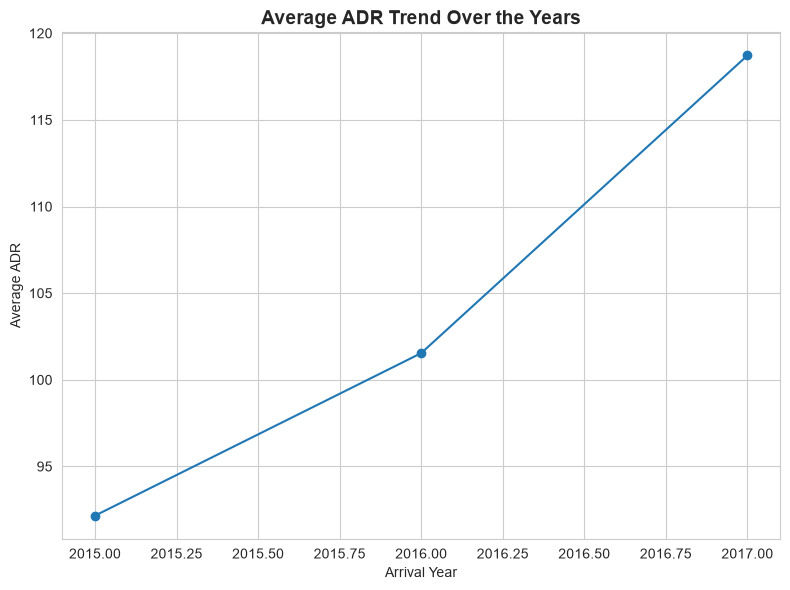

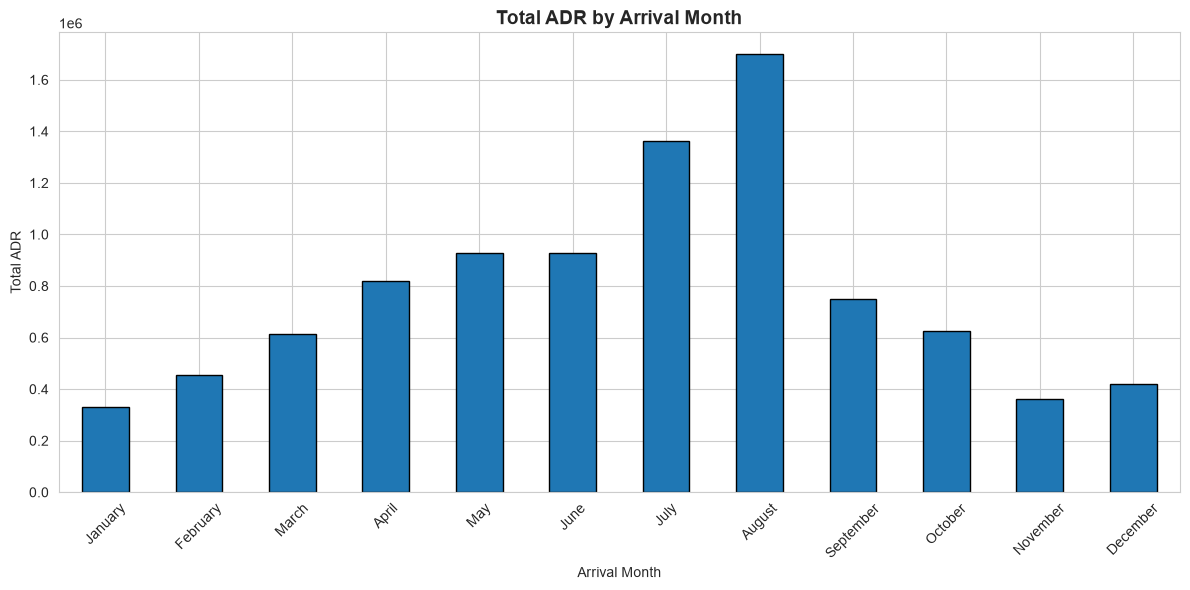

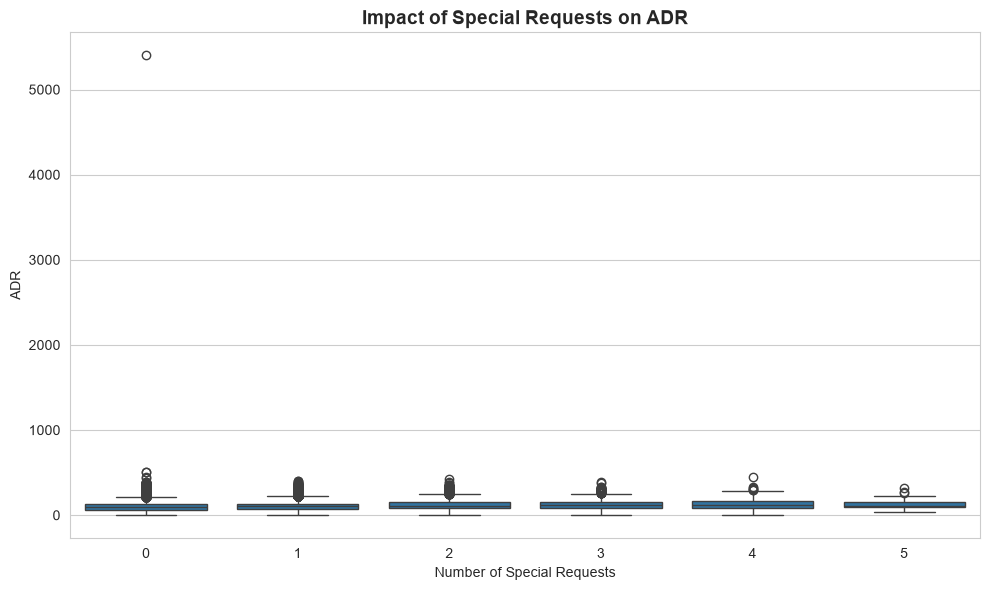

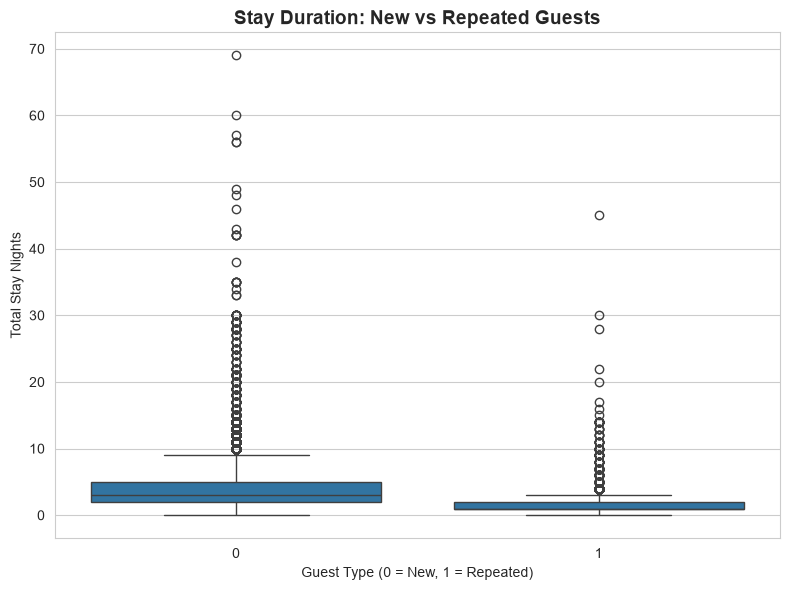

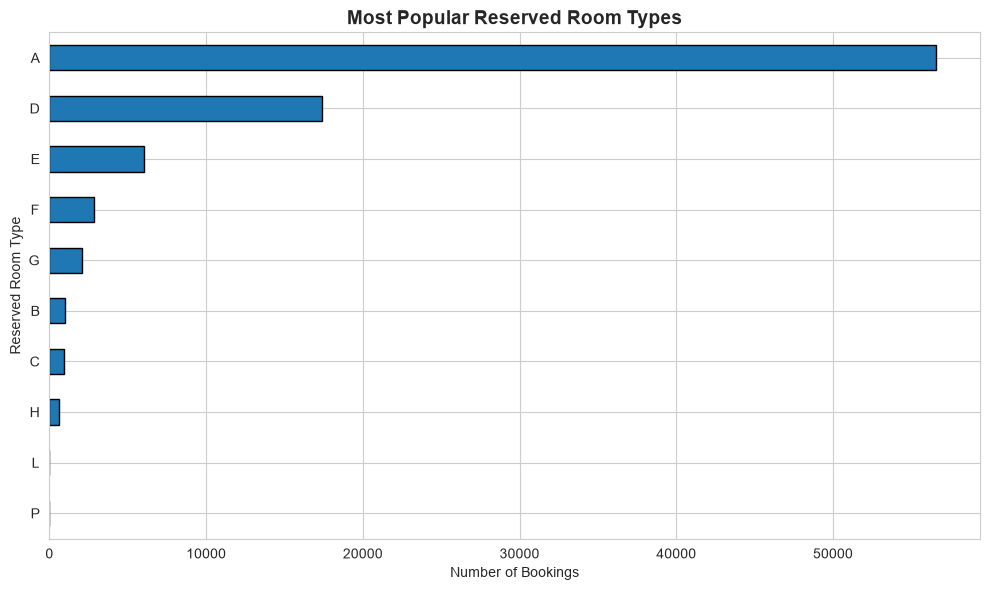

In [1]:
# ============================================================
# EDA2 - Hotel Operations Analysis
# Project: Hotel Harmony - Data Insights for Optimized Operations
# Dataset: hotel_bookings.csv
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings


warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# ============================================================
# 1. LOAD DATASET
# ============================================================

FILE_PATH = "hotel_bookings.csv"
hotel = pd.read_csv(r"C:\Users\hsami\Downloads\archive.zip")

print("=" * 70)
print("HOTEL OPERATIONS ANALYSIS - FILE LOADED SUCCESSFULLY")
print("=" * 70)
print(f"Dataset shape : {hotel.shape}")
print(f"Columns       : {hotel.columns.tolist()}")

# ============================================================
# 2. DATA PREVIEW
# ============================================================

print("\n" + "=" * 70)
print("HOTEL DATA - FIRST 5 ROWS")
print("=" * 70)
print(hotel.head())

print("\n" + "=" * 70)
print("RANDOM SAMPLE")
print("=" * 70)
print(hotel.sample(5, random_state=42))

# ============================================================
# 3. DATA INFO & MISSING VALUES
# ============================================================

print("\n" + "=" * 70)
print("DATA INFO")
print("=" * 70)
hotel.info()

print("\n" + "=" * 70)
print("MISSING VALUES")
print("=" * 70)
print(hotel.isnull().sum().sort_values(ascending=False))

# ============================================================
# 4. DATA CLEANING
# ============================================================

print("\n" + "=" * 70)
print("DATA CLEANING")
print("=" * 70)

# Keep a copy before cleaning
hotel_clean = hotel.copy()

# Missing values:
# Agent and company are IDs, so missing values are represented as "Unknown".
hotel_clean["agent"] = hotel_clean["agent"].fillna("Unknown")
hotel_clean["company"] = hotel_clean["company"].fillna("Unknown")

# Children has only a few missing values; use 0 as requested for
# numerical guest-count analysis.
hotel_clean["children"] = hotel_clean["children"].fillna(0)

# Country is categorical. Use Unknown for missing country values.
hotel_clean["country"] = hotel_clean["country"].fillna("Unknown")

# Convert date column to datetime
hotel_clean["reservation_status_date"] = pd.to_datetime(
    hotel_clean["reservation_status_date"],
    errors="coerce"
)

# Check duplicate rows
duplicate_count = hotel_clean.duplicated().sum()
print(f"Duplicate rows found: {duplicate_count}")

hotel_clean = hotel_clean.drop_duplicates().copy()

print(f"Shape after removing duplicates: {hotel_clean.shape}")

# Numeric columns
numeric_cols = [
    "is_canceled", "lead_time", "arrival_date_year",
    "arrival_date_week_number", "arrival_date_day_of_month",
    "stays_in_weekend_nights", "stays_in_week_nights",
    "adults", "children", "babies", "is_repeated_guest",
    "previous_cancellations", "previous_bookings_not_canceled",
    "booking_changes", "days_in_waiting_list", "adr",
    "required_car_parking_spaces", "total_of_special_requests"
]

for col in numeric_cols:
    hotel_clean[col] = pd.to_numeric(hotel_clean[col], errors="coerce")

# Remove the single negative ADR value because ADR cannot be negative
hotel_clean.loc[hotel_clean["adr"] < 0, "adr"] = np.nan

# Create total stay duration
hotel_clean["total_stay_nights"] = (
    hotel_clean["stays_in_weekend_nights"] +
    hotel_clean["stays_in_week_nights"]
)

# Create readable cancellation label
hotel_clean["cancellation_label"] = hotel_clean["is_canceled"].map(
    {0: "Not Canceled", 1: "Canceled"}
)

# Month order for correct plots
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

hotel_clean["arrival_date_month"] = pd.Categorical(
    hotel_clean["arrival_date_month"],
    categories=month_order,
    ordered=True
)

print("Cleaning completed successfully.")

# ============================================================
# 5. DESCRIPTIVE STATISTICS
# ============================================================

print("\n" + "=" * 70)
print("DESCRIPTIVE STATISTICS")
print("=" * 70)

print(hotel_clean[
    [
        "lead_time",
        "stays_in_weekend_nights",
        "stays_in_week_nights",
        "adults",
        "children",
        "babies",
        "adr",
        "total_of_special_requests"
    ]
].describe())

# ============================================================
# 6. BASIC LEVEL QUESTIONS
# ============================================================

print("\n" + "=" * 70)
print("BASIC LEVEL QUESTIONS - ANSWERS")
print("=" * 70)

# 1. Average lead time
avg_lead_time = hotel_clean["lead_time"].mean()
print(f"\n1. Average lead time for bookings: {avg_lead_time:.2f} days")

# 2. Distribution of bookings by hotel type
hotel_booking_counts = hotel_clean["hotel"].value_counts()
print("\n2. Bookings by hotel type:")
print(hotel_booking_counts)

# 3. Number of canceled bookings
canceled_bookings = hotel_clean["is_canceled"].sum()
print(f"\n3. Number of canceled bookings: {int(canceled_bookings)}")

# 4. Most common arrival month
common_month = hotel_clean["arrival_date_month"].value_counts().idxmax()
print(f"\n4. Most common arrival month: {common_month}")

# 5. Average special requests
avg_special_requests = hotel_clean["total_of_special_requests"].mean()
print(
    f"\n5. Average special requests per booking: "
    f"{avg_special_requests:.2f}"
)

# 6. Country with highest bookings
top_country = hotel_clean["country"].value_counts().idxmax()
top_country_count = hotel_clean["country"].value_counts().max()
print(
    f"\n6. Country with highest number of bookings: "
    f"{top_country} ({top_country_count} bookings)"
)

# 7. Average ADR for each hotel type
avg_adr_hotel = hotel_clean.groupby("hotel")["adr"].mean().sort_values(
    ascending=False
)
print("\n7. Average ADR by hotel type:")
print(avg_adr_hotel)

# 8. Percentage requiring car parking
parking_required = (hotel_clean["required_car_parking_spaces"] > 0).sum()
parking_percentage = (
    parking_required / len(hotel_clean)
) * 100
print(
    f"\n8. Percentage of bookings requiring car parking: "
    f"{parking_percentage:.2f}%"
)

# 9. Average week-night and weekend-night stay
avg_week_nights = hotel_clean["stays_in_week_nights"].mean()
avg_weekend_nights = hotel_clean["stays_in_weekend_nights"].mean()

print(
    f"\n9. Average week-night stay: {avg_week_nights:.2f} nights"
)
print(
    f"   Average weekend-night stay: {avg_weekend_nights:.2f} nights"
)

# 10. Bookings made through travel agents
# Count non-null/known agent IDs after cleaning.
agent_bookings = (hotel_clean["agent"] != "Unknown").sum()
print(
    f"\n10. Bookings made through travel agents: "
    f"{agent_bookings}"
)

# ============================================================
# 7. BASIC LEVEL VISUALIZATIONS
# ============================================================

# --- 7.1 Bookings by Hotel Type ---
plt.figure(figsize=(8, 6))
hotel_booking_counts.plot(
    kind="bar",
    edgecolor="black"
)
plt.title("Distribution of Bookings by Hotel Type",
          fontsize=14, fontweight="bold")
plt.xlabel("Hotel Type")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# --- 7.2 Booking Distribution by Arrival Month ---
monthly_bookings = (
    hotel_clean["arrival_date_month"]
    .value_counts()
    .reindex(month_order)
)

plt.figure(figsize=(12, 6))
monthly_bookings.plot(
    kind="bar",
    edgecolor="black"
)
plt.title("Bookings by Arrival Month",
          fontsize=14, fontweight="bold")
plt.xlabel("Arrival Month")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- 7.3 Cancellation Distribution ---
plt.figure(figsize=(8, 6))
hotel_clean["cancellation_label"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Booking Cancellation Distribution",
          fontsize=14, fontweight="bold")
plt.ylabel("")
plt.tight_layout()
plt.show()

# --- 7.4 Special Requests Distribution ---
plt.figure(figsize=(10, 6))
hotel_clean["total_of_special_requests"].value_counts().sort_index().plot(
    kind="bar",
    edgecolor="black"
)
plt.title("Frequency of Special Requests",
          fontsize=14, fontweight="bold")
plt.xlabel("Number of Special Requests")
plt.ylabel("Number of Bookings")
plt.tight_layout()
plt.show()

# --- 7.5 Average ADR by Hotel Type ---
plt.figure(figsize=(8, 6))
avg_adr_hotel.plot(
    kind="bar",
    edgecolor="black"
)
plt.title("Average ADR by Hotel Type",
          fontsize=14, fontweight="bold")
plt.xlabel("Hotel Type")
plt.ylabel("Average ADR")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# --- 7.6 Top 10 Countries by Bookings ---
top_countries = hotel_clean["country"].value_counts().head(10)

plt.figure(figsize=(12, 6))
top_countries.sort_values().plot(
    kind="barh",
    edgecolor="black"
)
plt.title("Top 10 Countries by Number of Bookings",
          fontsize=14, fontweight="bold")
plt.xlabel("Number of Bookings")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

# ============================================================
# 8. MEDIUM LEVEL QUESTIONS
# ============================================================

print("\n" + "=" * 70)
print("MEDIUM LEVEL QUESTIONS - ANSWERS")
print("=" * 70)

# 1. Cancellation rate for each hotel type
cancellation_rate_hotel = (
    hotel_clean.groupby("hotel")["is_canceled"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print("\n1. Cancellation rate for each hotel type (%):")
print(cancellation_rate_hotel)

# 2. Average ADR per market segment
avg_adr_segment = (
    hotel_clean.groupby("market_segment")["adr"]
    .mean()
    .sort_values(ascending=False)
)

print("\n2. Average ADR per market segment:")
print(avg_adr_segment)

# 3. Relationship between lead time and cancellation rate
lead_time_cancel_corr = hotel_clean[
    ["lead_time", "is_canceled"]
].corr().loc["lead_time", "is_canceled"]

print(
    f"\n3. Correlation between lead time and cancellation: "
    f"{lead_time_cancel_corr:.4f}"
)

# 4. Distribution channel with highest bookings
channel_counts = hotel_clean["distribution_channel"].value_counts()
top_distribution_channel = channel_counts.idxmax()

print("\n4. Distribution channel booking counts:")
print(channel_counts)
print(
    f"Highest booking distribution channel: "
    f"{top_distribution_channel}"
)

# 5. Average previous cancellations by hotel type
avg_previous_cancellations = (
    hotel_clean.groupby("hotel")["previous_cancellations"]
    .mean()
)

print("\n5. Average previous cancellations by hotel type:")
print(avg_previous_cancellations)

# 6. Trend of ADR over years
adr_year = (
    hotel_clean.groupby("arrival_date_year")["adr"]
    .mean()
)

print("\n6. Average ADR by year:")
print(adr_year)

# 7. Month with highest revenue proxy
# Following the project solution idea, sum ADR by arrival month.
monthly_revenue = (
    hotel_clean.groupby("arrival_date_month", observed=False)["adr"]
    .sum()
    .reindex(month_order)
)

highest_revenue_month = monthly_revenue.idxmax()

print("\n7. Total ADR by month (revenue proxy):")
print(monthly_revenue)
print(
    f"Month with highest total ADR: {highest_revenue_month}"
)

# 8. Impact of special requests on ADR
special_adr_corr = hotel_clean[
    ["total_of_special_requests", "adr"]
].corr().loc["total_of_special_requests", "adr"]

print(
    f"\n8. Correlation between special requests and ADR: "
    f"{special_adr_corr:.4f}"
)

# 9. Average stay duration - repeated vs new guests
avg_stay_repeated = (
    hotel_clean.groupby("is_repeated_guest")["total_stay_nights"]
    .mean()
)

avg_stay_repeated.index = avg_stay_repeated.index.map(
    {0: "New Guest", 1: "Repeated Guest"}
)

print("\n9. Average stay duration - repeated vs new guests:")
print(avg_stay_repeated)

# 10. Room type with highest number of bookings
room_counts = hotel_clean["reserved_room_type"].value_counts()
top_room_type = room_counts.idxmax()

print("\n10. Reserved room type booking counts:")
print(room_counts)
print(f"Most booked room type: {top_room_type}")

# ============================================================
# 9. MEDIUM LEVEL VISUALIZATIONS
# ============================================================

# --- 9.1 Cancellation Rate by Hotel ---
plt.figure(figsize=(8, 6))
cancellation_rate_hotel.plot(
    kind="bar",
    edgecolor="black"
)
plt.title("Cancellation Rate by Hotel Type",
          fontsize=14, fontweight="bold")
plt.xlabel("Hotel Type")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# --- 9.2 Average ADR by Market Segment ---
plt.figure(figsize=(12, 6))
avg_adr_segment.plot(
    kind="bar",
    edgecolor="black"
)
plt.title("Average ADR by Market Segment",
          fontsize=14, fontweight="bold")
plt.xlabel("Market Segment")
plt.ylabel("Average ADR")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- 9.3 Lead Time vs Cancellation ---
plt.figure(figsize=(10, 6))
sample_data = hotel_clean.sample(
    min(10000, len(hotel_clean)),
    random_state=42
)

sns.scatterplot(
    x="lead_time",
    y="is_canceled",
    data=sample_data,
    alpha=0.35
)

plt.title("Lead Time vs Cancellation",
          fontsize=14, fontweight="bold")
plt.xlabel("Lead Time (Days)")
plt.ylabel("Canceled (0 = No, 1 = Yes)")
plt.tight_layout()
plt.show()

# --- 9.4 ADR Trend Over Years ---
plt.figure(figsize=(8, 6))
adr_year.plot(
    kind="line",
    marker="o"
)
plt.title("Average ADR Trend Over the Years",
          fontsize=14, fontweight="bold")
plt.xlabel("Arrival Year")
plt.ylabel("Average ADR")
plt.grid(True)
plt.tight_layout()
plt.show()

# --- 9.5 Monthly Revenue Proxy ---
plt.figure(figsize=(12, 6))
monthly_revenue.plot(
    kind="bar",
    edgecolor="black"
)
plt.title("Total ADR by Arrival Month",
          fontsize=14, fontweight="bold")
plt.xlabel("Arrival Month")
plt.ylabel("Total ADR")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- 9.6 Special Requests vs ADR ---
plt.figure(figsize=(10, 6))
sns.boxplot(
    x="total_of_special_requests",
    y="adr",
    data=hotel_clean
)
plt.title("Impact of Special Requests on ADR",
          fontsize=14, fontweight="bold")
plt.xlabel("Number of Special Requests")
plt.ylabel("ADR")
plt.tight_layout()
plt.show()

# --- 9.7 Stay Duration: New vs Repeated Guests ---
plt.figure(figsize=(8, 6))
sns.boxplot(
    x="is_repeated_guest",
    y="total_stay_nights",
    data=hotel_clean
)
plt.title("Stay Duration: New vs Repeated Guests",
          fontsize=14, fontweight="bold")
plt.xlabel("Guest Type (0 = New, 1 = Repeated)")
plt.ylabel("Total Stay Nights")
plt.tight_layout()
plt.show()

# --- 9.8 Top Reserved Room Types ---
top_rooms = room_counts.head(10)

plt.figure(figsize=(10, 6))
top_rooms.sort_values().plot(
    kind="barh",
    edgecolor="black"
)
plt.title("Most Popular Reserved Room Types",
          fontsize=14, fontweight="bold")
plt.xlabel("Number of Bookings")
plt.ylabel("Reserved Room Type")
plt.tight_layout()
plt.show()

